# monoT5 Reranking

This notebook builds a pointwise T5 reranking run with `castorini/monot5-base-msmarco`.

monoT5 scores each query-passage pair independently using an input of the form:

`Query: q Document: d Relevant:`

and reads the probability of generating `true` at the first decoder step. These scores are then used to rank candidate passages.

The notebook saves a TREC-style run file that can be used directly by the DuoT5 notebook as its first-stage neural ranking input.


In [1]:
# -- IMPORTS --
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer


/Users/evelinalune/Documents/uni/MSc-IS/thesis/ig-thesis/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
queries_file = "../data/msmarco_passage_dev/raw/queries.dev.tsv"
candidates_file = "../data/msmarco_passage_dev/raw/top1000.dev"
qrels_file = "../data/msmarco_passage_dev/raw/qrels.dev.tsv"

out_dir = Path("../outputs_monot5")
out_dir.mkdir(exist_ok=True)

model_name = "castorini/monot5-base-msmarco"

# For a thesis pilot this is a good compromise: enough depth for DuoT5 top-50,
# but still much cheaper than reranking the full top-1000.
top_k = 100
batch_size = 8
max_length = 512
max_pairs_per_query = 5
n_queries = 100

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


In [3]:
queries = pd.read_csv(queries_file, sep="\t", header=None, names=["qid", "query"])
queries["qid"] = queries["qid"].astype(str)
query_map_all = dict(zip(queries["qid"], queries["query"]))

candidate_qids = set(
    pd.read_csv(candidates_file, sep="\t", header=None, usecols=[0], names=["qid"])["qid"].astype(str)
)
qrel_qids = set(pd.read_csv(qrels_file, sep="\t", header=None, usecols=[0], names=["qid"])["qid"].astype(str))

eligible_qids = [qid for qid in query_map_all if qid in candidate_qids and qid in qrel_qids]
query_map = {qid: query_map_all[qid] for qid in eligible_qids[:n_queries]}

print(f"Pilot queries with candidates and qrels: {len(query_map)}")
print(f"Queries loaded: {len(query_map):,}")


Pilot queries with candidates and qrels: 100
Queries loaded: 100


In [4]:
candidates_df = pd.read_csv(
    candidates_file,
    sep="\t",
    header=None,
    names=["qid", "pid", "query", "passage"],
)
candidates_df["qid"] = candidates_df["qid"].astype(str)
candidates_df["pid"] = candidates_df["pid"].astype(str)

candidates_df = candidates_df[candidates_df["qid"].isin(query_map)]
candidates_df = candidates_df.groupby("qid", sort=False).head(top_k).reset_index(drop=True)

print(f"Candidate rows (after top_k={top_k} filter): {len(candidates_df):,}")


Candidate rows (after top_k=100 filter): 9,339


In [5]:
qrels_df = pd.read_csv(
    qrels_file,
    sep="\t",
    header=None,
    names=["qid", "_", "pid", "relevance"],
)
qrels_df["qid"] = qrels_df["qid"].astype(str)
qrels_df["pid"] = qrels_df["pid"].astype(str)

qrel_map = {(row.qid, row.pid): row.relevance for row in qrels_df.itertuples()}
print(f"Qrel entries: {len(qrel_map):,}")


Qrel entries: 59,273


In [6]:
try:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
except Exception as e:
    raise ImportError(
        "Failed to load the monoT5 tokenizer. Install the required tokenizer dependencies, "
        "for example `pip install sentencepiece protobuf`, restart the kernel, and rerun."
    ) from e

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = model.to(device)
model.eval()

true_ids = tokenizer.encode("true", add_special_tokens=False)
false_ids = tokenizer.encode("false", add_special_tokens=False)
if len(true_ids) != 1 or len(false_ids) != 1:
    raise ValueError("Expected 'true' and 'false' to map to single tokens for monoT5 scoring.")

true_token_id = true_ids[0]
false_token_id = false_ids[0]
decoder_start_token_id = model.config.decoder_start_token_id
if decoder_start_token_id is None:
    decoder_start_token_id = tokenizer.pad_token_id

print(f"Loaded: {model_name}")
print(f"Device: {device}")
print(f"true token id: {true_token_id}")
print(f"false token id: {false_token_id}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loaded: castorini/monot5-base-msmarco
Device: mps
true token id: 1176
false token id: 6136


## monoT5 Scoring

The monoT5 score is the probability of generating `true` rather than `false` for a single query-passage pair.


In [7]:
def mono_input(query, passage):
    return f"Query: {query} Document: {passage} Relevant:"

def monot5_true_probs(texts, batch_size=batch_size):
    probs = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        batch = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        batch = {k: v.to(device) for k, v in batch.items()}

        decoder_input_ids = torch.full(
            (len(batch_texts), 1),
            decoder_start_token_id,
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            outputs = model(**batch, decoder_input_ids=decoder_input_ids)

        logits = outputs.logits[:, 0, :]
        tf_logits = logits[:, [false_token_id, true_token_id]]
        batch_probs = torch.softmax(tf_logits, dim=-1)[:, 1].detach().cpu().numpy()
        probs.extend(batch_probs.tolist())

    return np.array(probs, dtype=float)


In [8]:
ranked_results = {}

for qid, group in tqdm(candidates_df.groupby("qid"), desc="monoT5 reranking queries"):
    query_text = query_map[qid]
    passages = group["passage"].tolist()
    pids = group["pid"].tolist()

    inputs = [mono_input(query_text, passage) for passage in passages]
    scores = monot5_true_probs(inputs, batch_size=batch_size)
    order = np.argsort(scores)[::-1]

    ranked_results[qid] = [
        {
            "pid": pids[i],
            "passage": passages[i],
            "score": float(scores[i]),
            "rank": rank + 1,
            "relevant": int(qrel_map.get((qid, pids[i]), 0) > 0),
        }
        for rank, i in enumerate(order)
    ]

print(f"\nReranked {len(ranked_results):,} queries.")


monoT5 reranking queries:   0%|          | 0/100 [00:00<?, ?it/s]


Reranked 100 queries.


In [9]:
all_scores = [entry["score"] for results in ranked_results.values() for entry in results]
print(f"Score range: [{min(all_scores):.3f}, {max(all_scores):.3f}]")
print(f"Score mean: {np.mean(all_scores):.3f}")
print(f"Score median: {np.median(all_scores):.3f}")


Score range: [0.000, 0.999]
Score mean: 0.059
Score median: 0.000


In [10]:
rel_ranks, nonrel_ranks = [], []
for results in ranked_results.values():
    for entry in results:
        (rel_ranks if entry["relevant"] else nonrel_ranks).append(entry["rank"])

print(f"Mean rank of RELEVANT passages: {np.mean(rel_ranks):.1f}")
print(f"Mean rank of NON-RELEVANT passages: {np.mean(nonrel_ranks):.1f}")
print("(Lower rank = higher in the list; relevant passages should rank lower.)")


Mean rank of RELEVANT passages: 3.1
Mean rank of NON-RELEVANT passages: 50.0
(Lower rank = higher in the list; relevant passages should rank lower.)


In [11]:
pairwise_records = []
rng = np.random.default_rng(seed)

for qid, results in ranked_results.items():
    query_text = query_map[qid]
    rel_entries = [entry for entry in results if entry["relevant"]]
    nonrel_entries = [entry for entry in results if not entry["relevant"]]

    if not rel_entries or not nonrel_entries:
        continue

    pairs = [(di, dj) for di in rel_entries for dj in nonrel_entries]
    if max_pairs_per_query and len(pairs) > max_pairs_per_query:
        idx = rng.choice(len(pairs), size=max_pairs_per_query, replace=False)
        pairs = [pairs[i] for i in idx]

    for di, dj in pairs:
        g = di["score"] - dj["score"]
        pairwise_records.append({
            "qid": qid,
            "query": query_text,
            "pid_i": di["pid"],
            "passage_i": di["passage"],
            "score_i": di["score"],
            "pid_j": dj["pid"],
            "passage_j": dj["passage"],
            "score_j": dj["score"],
            "g_score": g,
            "correct_pref": int(g > 0),
        })

pairs_df = pd.DataFrame(pairwise_records)
print(f"Total pairwise pairs: {len(pairs_df):,}")
print(f"Queries covered: {pairs_df['qid'].nunique():,}")
print(f"\nModel preference accuracy (g > 0): {pairs_df['correct_pref'].mean():.1%}")


Total pairwise pairs: 90
Queries covered: 18

Model preference accuracy (g > 0): 95.6%


In [12]:
ranked_out = out_dir / "ranked_results.pkl"
with open(ranked_out, "wb") as f:
    pickle.dump(ranked_results, f)
print(f"Saved ranked results → {ranked_out}")

ranked_flat = out_dir / "ranked_results.csv"
rows = [{"qid": qid, **entry} for qid, results in ranked_results.items() for entry in results]
pd.DataFrame(rows).to_csv(ranked_flat, index=False)
print(f"Saved ranked results (flat CSV) → {ranked_flat}")

mono_run_out = out_dir / "mono_run.txt"
run_rows = []
for qid, results in ranked_results.items():
    for entry in results:
        run_rows.append([
            qid,
            "Q0",
            entry["pid"],
            entry["rank"],
            entry["score"],
            "monoT5",
        ])

pd.DataFrame(run_rows).to_csv(mono_run_out, sep=" ", header=False, index=False)
print(f"Saved TREC run file → {mono_run_out}")


Saved ranked results → ../outputs_monot5/ranked_results.pkl
Saved ranked results (flat CSV) → ../outputs_monot5/ranked_results.csv
Saved TREC run file → ../outputs_monot5/mono_run.txt


In [13]:
pairs_pkl = out_dir / "pairwise_scores.pkl"
pairs_csv = out_dir / "pairwise_scores.csv"
pairs_parquet = out_dir / "pairwise_scores.parquet"

pairs_df.to_pickle(pairs_pkl)
pairs_df.to_csv(pairs_csv, index=False)
print(f"Saved pairwise scores (pkl) → {pairs_pkl}")
print(f"Saved pairwise scores (csv) → {pairs_csv}")

try:
    pairs_df.to_parquet(pairs_parquet, index=False)
    print(f"Saved pairwise scores (parquet) → {pairs_parquet}")
except Exception as e:
    print(f"Skipping parquet save: {e}")


Saved pairwise scores (pkl) → ../outputs_monot5/pairwise_scores.pkl
Saved pairwise scores (csv) → ../outputs_monot5/pairwise_scores.csv
Saved pairwise scores (parquet) → ../outputs_monot5/pairwise_scores.parquet


In [14]:
mono_rr_records = []

for qid, results in ranked_results.items():
    query_text = query_map[qid]
    first_rel_rank = None
    for entry in results:
        if entry["relevant"] == 1:
            first_rel_rank = entry["rank"]
            break

    rr = 1 / first_rel_rank if first_rel_rank else 0.0
    mono_rr_records.append({
        "query_id": qid,
        "query": query_text,
        "first_rel_rank": first_rel_rank,
        "rr": rr,
    })

mono_rr_df = pd.DataFrame(mono_rr_records)
print(f"Queries evaluated: {len(mono_rr_df)}")
print(f"Mean Reciprocal Rank (MRR): {mono_rr_df['rr'].mean():.4f}")
print(f"Queries with no relevant in top-{top_k}: {mono_rr_df['first_rel_rank'].isna().sum()}")


Queries evaluated: 100
Mean Reciprocal Rank (MRR): 0.1406
Queries with no relevant in top-100: 82


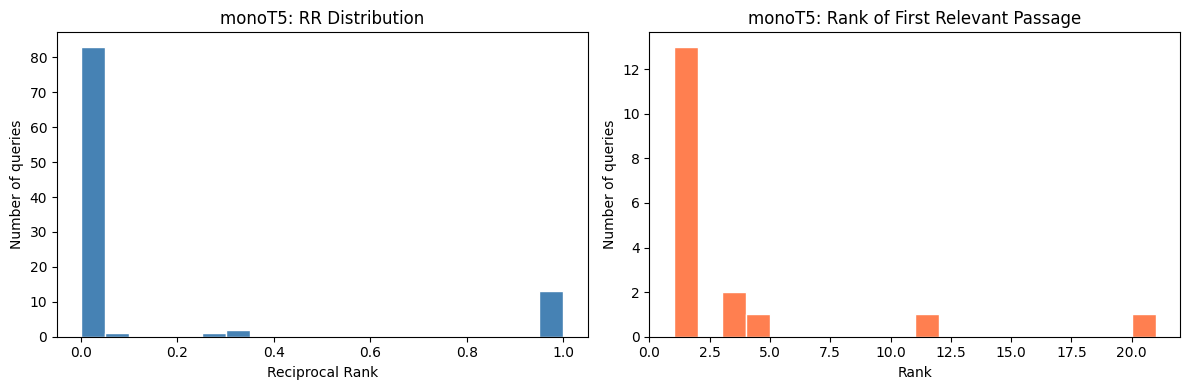

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mono_rr_df["rr"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("monoT5: RR Distribution")
axes[0].set_xlabel("Reciprocal Rank")
axes[0].set_ylabel("Number of queries")

axes[1].hist(mono_rr_df["first_rel_rank"].dropna(), bins=20, color="coral", edgecolor="white")
axes[1].set_title("monoT5: Rank of First Relevant Passage")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()


In [16]:
print("monoT5 Reranker Summary:")
print(f"MRR@{top_k}: {mono_rr_df['rr'].mean():.4f}")
print(f"Recall@1 (rel at rank 1): {(mono_rr_df['first_rel_rank'] == 1).mean():.1%}")
print(f"Recall@5 (rel in top 5): {(mono_rr_df['first_rel_rank'] <= 5).mean():.1%}")
print(f"Recall@10 (rel in top 10): {(mono_rr_df['first_rel_rank'] <= 10).mean():.1%}")
print(f"Saved mono run for DuoT5: {mono_run_out}")


monoT5 Reranker Summary:
MRR@100: 0.1406
Recall@1 (rel at rank 1): 13.0%
Recall@5 (rel in top 5): 16.0%
Recall@10 (rel in top 10): 16.0%
Saved mono run for DuoT5: ../outputs_monot5/mono_run.txt
